# SPCA Classification - zoo data

This notebook performs supervised PCA with classification on a zoological dataset with 100+ animals. Each animal is annotated with 16 attributes (has hair, has feathers, flies etc.) and belongs to one of 7 classes (mammal, fish, etc.).

The SPCA Classification model jointly learns a 2D latent projection and a linear classifier, balancing reconstruction and classification objectives via the regularization parameter $\lambda$.

In [71]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch
import matplotlib.pyplot as plt
import numpy as np

from models.spca_classification import SPCA_Classification
from utils import load_zoo_data, scale_features

In [72]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data preparation

In [73]:
# Load zoo data
E_raw, C, names, feature_names, class_names = load_zoo_data(device)

# Scale and center features
E = scale_features(E_raw)
E = E - E.mean(dim=0)

## Model training

We train the SPCA Classification model with $\lambda = 0.01$, which puts more weight on the supervised classification error while retaining some unsupervised reconstruction signal.

In [74]:
# Initialize SPCA classification model
model = SPCA_Classification(input_dim=E.shape[1], latent_dim=2, num_classes=len(class_names), lr=0.05).to(device)

# Train model
lam = 0.01  # regularization parameter lambda
steps = 100
model.train(E, C, lam=lam, steps=steps, classifier_epochs=50)

Step 0: loss = 3.1467, classifier loss = 1.8483
Step 10: loss = 2.4860, classifier loss = 1.1836
Step 20: loss = 2.2192, classifier loss = 0.9143
Step 30: loss = 2.0940, classifier loss = 0.7880
Step 40: loss = 2.0184, classifier loss = 0.7115
Step 50: loss = 1.9641, classifier loss = 0.6565
Step 60: loss = 1.9211, classifier loss = 0.6128
Step 70: loss = 1.8851, classifier loss = 0.5761
Step 80: loss = 1.8542, classifier loss = 0.5447
Step 90: loss = 1.8270, classifier loss = 0.5171


## Visualization

### SPCA projection

First, we visualize the data projected onto the first two supervised principal components, without the feature loadings.

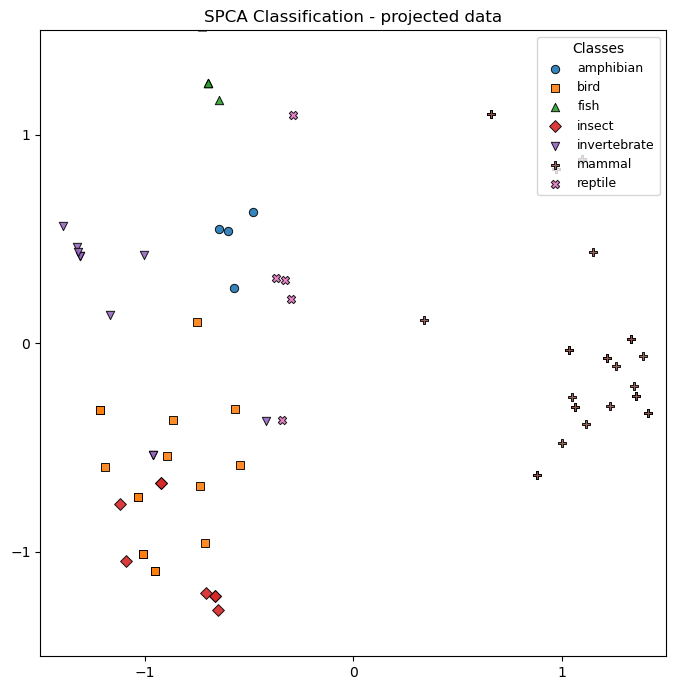

In [75]:
# Extract latent projections
L = model.L.detach()
Z = E @ L

Z_np = Z.cpu().numpy()
C_np = C.cpu().numpy()

unique_classes = np.unique(C_np)
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>']
cmap = plt.get_cmap('tab10')

plt.figure(figsize=(7, 7))

for i, cls in enumerate(unique_classes):
    idx = C_np == cls
    plt.scatter(
        Z_np[idx, 0],
        Z_np[idx, 1],
        color=cmap(i % 10),
        marker=markers[i % len(markers)],
        label=class_names[int(cls)],
        edgecolors='black',
        linewidths=0.7,
        alpha=0.9
    )

plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.xticks([-1, 0, 1])
plt.yticks([-1, 0, 1])
plt.gca().set_aspect('equal', 'box')

plt.legend(title="Classes", loc='upper right', frameon=True, fontsize=9, title_fontsize=10)

plt.title("SPCA Classification - projected data")
plt.tight_layout()
plt.show()

### Projection with feature loadings

Now we overlay the feature loading vectors to see which attributes drive the projection.

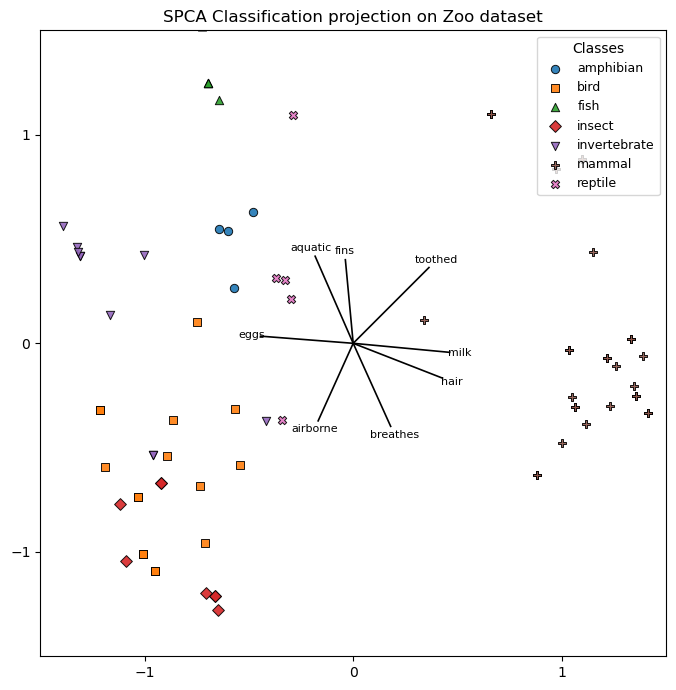

In [76]:
# Prepare for visualization with loadings
L_np = L.cpu().numpy()

plt.figure(figsize=(7, 7))
# Plot points by class
for i, cls in enumerate(unique_classes):
    idx = C_np == cls
    plt.scatter(
        Z_np[idx, 0],
        Z_np[idx, 1],
        color=cmap(i % 10),
        marker=markers[i % len(markers)],
        label=class_names[int(cls)],
        edgecolors="black",
        linewidths=0.7,
        alpha=0.9
    )
# Plot projection vectors (loadings of features) with labels
for i, vec in enumerate(L_np):
    x, y = vec
    length = np.sqrt(x**2 + y**2)
    if length > 0.4:
        plt.plot([0, x], [0, y], linestyle="-", linewidth=1.2, color="black")
        plt.text(
            x * 1.1, y * 1.1,
            feature_names[i],
            fontsize=8,
            ha="center",
            va="center"
        )

# Configure axes
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.xticks([-1, 0, 1])
plt.yticks([-1, 0, 1])
plt.gca().set_aspect("equal", "box")

plt.legend(title="Classes", loc="upper right", frameon=True, fontsize=9, title_fontsize=10)

plt.title("SPCA Classification projection on Zoo dataset")
plt.tight_layout()
plt.show()

Step 0: loss = 3.1458, classifier loss = 1.8474
Step 10: loss = 2.4849, classifier loss = 1.1822
Step 20: loss = 2.2187, classifier loss = 0.9136
Step 30: loss = 2.0939, classifier loss = 0.7877
Step 40: loss = 2.0185, classifier loss = 0.7113
Step 50: loss = 1.9642, classifier loss = 0.6564
Step 60: loss = 1.9212, classifier loss = 0.6128
Step 70: loss = 1.8853, classifier loss = 0.5762
Step 80: loss = 1.8544, classifier loss = 0.5448
Step 90: loss = 1.8273, classifier loss = 0.5172
Step 0: loss = 14.8550, classifier loss = 1.8531
Step 10: loss = 14.1963, classifier loss = 1.1929
Step 20: loss = 13.9303, classifier loss = 0.9261
Step 30: loss = 13.8058, classifier loss = 0.8012
Step 40: loss = 13.7308, classifier loss = 0.7261
Step 50: loss = 13.6772, classifier loss = 0.6724
Step 60: loss = 13.6347, classifier loss = 0.6299
Step 70: loss = 13.5994, classifier loss = 0.5944
Step 80: loss = 13.5690, classifier loss = 0.5639
Step 90: loss = 13.5424, classifier loss = 0.5372
Step 0: loss

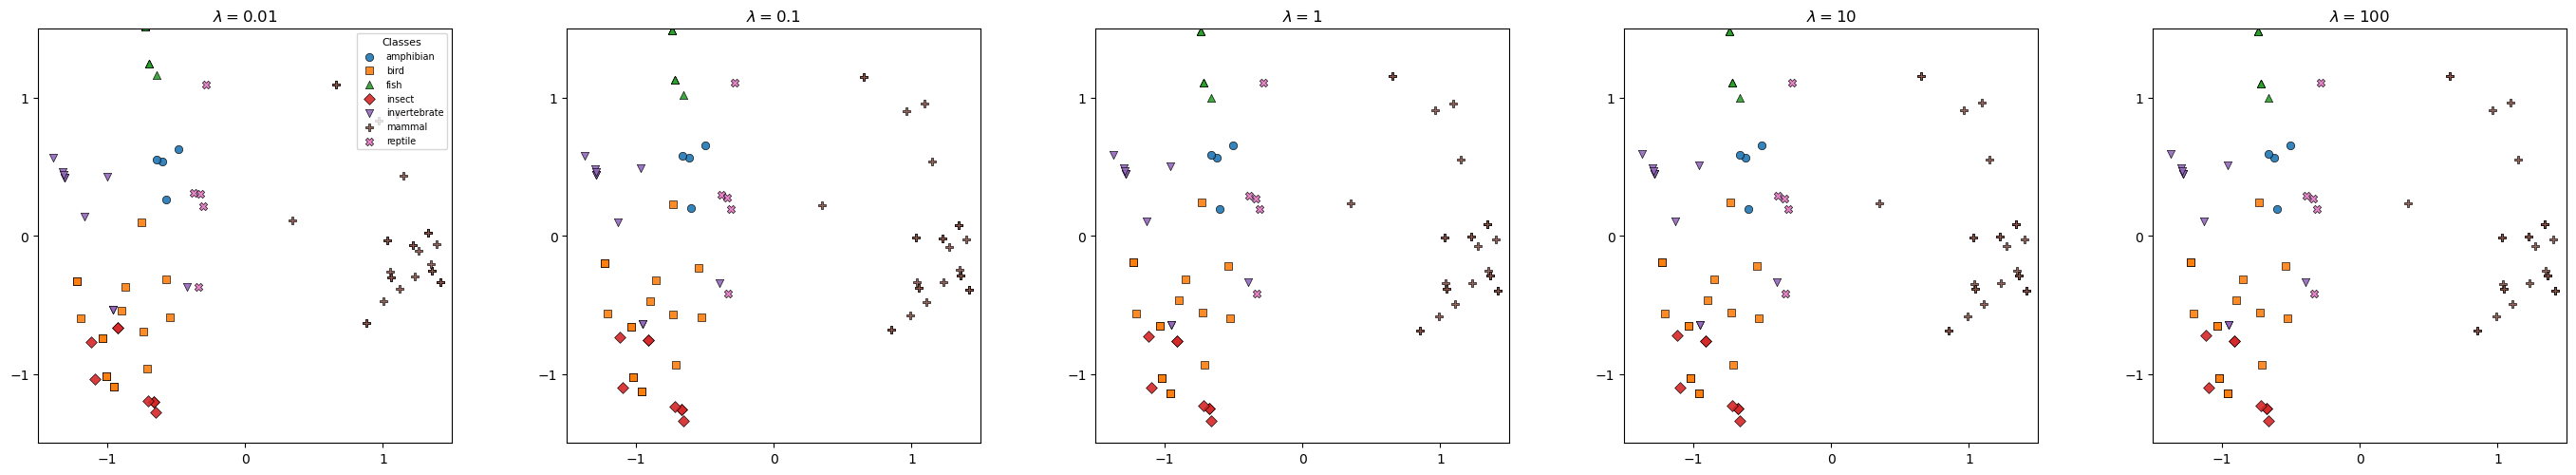

In [77]:
# SPCA projections for different lambda values
lambdas = [0.01, 0.1, 1, 10, 100]
markers = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]
cmap = plt.get_cmap("tab10")

fig, axes = plt.subplots(1, 5, figsize=(28, 5))

for ax, lam in zip(axes, lambdas):
    model = SPCA_Classification(input_dim=E.shape[1], latent_dim=2, num_classes=len(class_names), lr=0.05).to(device)
    model.train(E, C, lam=lam, steps=100, classifier_epochs=50)

    L = model.L.detach()
    Z = (E @ L).cpu().numpy()
    C_np = C.cpu().numpy()
    unique_classes = np.unique(C_np)

    for i, cls in enumerate(unique_classes):
        idx = C_np == cls
        ax.scatter(
            Z[idx, 0],
            Z[idx, 1],
            color=cmap(i % 10),
            marker=markers[i % len(markers)],
            label=class_names[int(cls)],
            edgecolors="black",
            linewidths=0.5,
            alpha=0.9
        )

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    ax.set_aspect("equal", "box")
    ax.set_title(r"$\lambda = $" + f"{lam}")

axes[0].legend(title="Classes", loc="upper right", frameon=True, fontsize=7, title_fontsize=8)
plt.tight_layout()
plt.show()